# Week 3 — Discrete Signal Toolbox: Framing and Comparison

**Story question:** How can we locate and compare the same event when it occurs at different times or speeds?

**Flow:** long recording → frames with start times → normalize → Euclidean distance → normalized cross-correlation → moving average → DTW for a stretched event.

In [1]:
# !uv pip install numpy matplotlib scipy scikit-learn 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def time_axis(fs, duration):
    T = 1/fs
    t = np.arange(0, duration, T)
    return t

def generate_sine(f, t, A=1, p=0):
    y = A * np.sin(2 * np.pi * f * t + p)
    return y

fs = 200          # sampling rate (Hz)
duration = 10     # seconds
t = time_axis(fs, duration)

In [3]:
def make_event(fs, f=25, tau=0.06, length_s=0.25, A=1.0, stretch=1.0):
    te = time_axis(fs, length_s * stretch)
    y = A * np.exp(-te / (tau * stretch)) * generate_sine(f / stretch, te)
    return y

def place_events(x, fs, events):
    for start_s, A in events:
        e = make_event(fs, A=A)
        i0 = int(round(start_s * fs))
        x[i0:i0+len(e)] += e
    return x

x = np.random.normal(0, 0.08, len(t))  # สร้างสัญญาณสุ่มค่า 0 - 0.08 
x = place_events(x, fs, [(1.5, 1.0), (4.2, 0.5), (7.6, 1.3)]) # สร้างสัญญาณ sine ณ (ตำแหน่ง, ค่า) ที่กำหนด
template = make_event(fs, A=1.0)
print(x.shape, template.shape, round(float(x.max()), 3))

(2000,) (50,) 1.048


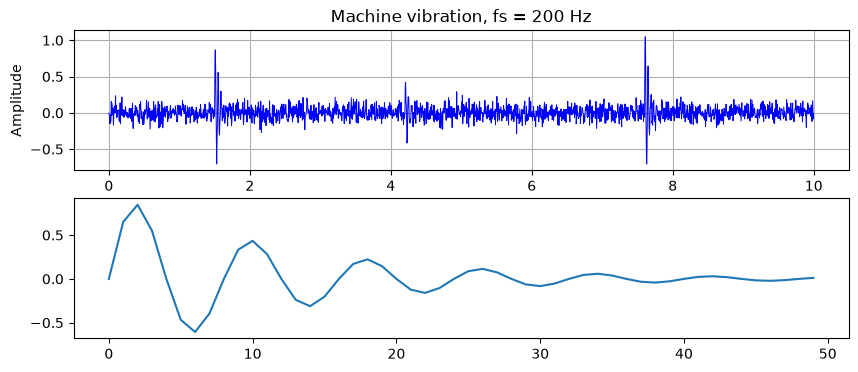

In [4]:
plt.figure(figsize=(10, 4))
plt.subplot(2,1,1)
plt.plot(t, x, color='b', linewidth=0.7)
plt.xlabel("Time (sec)")
plt.ylabel("Amplitude")
plt.title(f"Machine vibration, fs = {fs} Hz")
plt.grid()

plt.subplot(2,1,2)
plt.plot(template)
plt.show()

Windowing

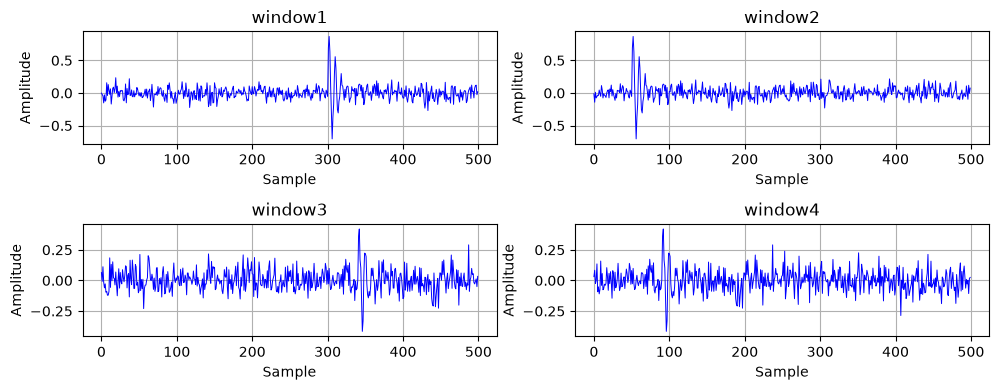

In [5]:
L = 500 # 500 samples per window
H = int(0.5 * L) # overlap 50%
p0 = 0 # starting point
p1 = L # stoping point

plt.figure(figsize=(10, 4))
for i in range(1, 4+1):
    x_win = x[p0:p1]
    
    plt.subplot(2,2,i)
    plt.plot(x_win, color='b', linewidth=0.7)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title(f"window{i}")
    plt.grid()

    p0 += H
    p1 += H

plt.tight_layout()
plt.show()

In [6]:
import numpy as np
from numpy.lib.stride_tricks import sliding_window_view

data = np.array([10, 20, 30, 40, 50, 60])

windows = sliding_window_view(data, window_shape=4)
print(windows)

print(windows[::2])

[[10 20 30 40]
 [20 30 40 50]
 [30 40 50 60]]
[[10 20 30 40]
 [30 40 50 60]]


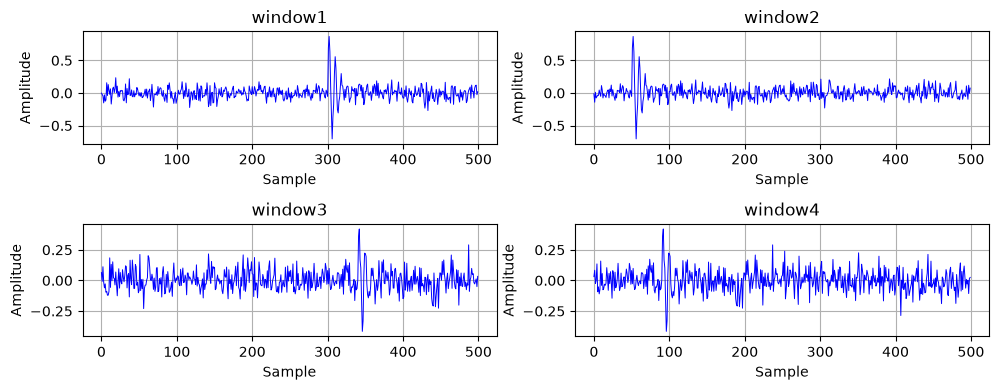

In [7]:
L = 500
H = int(0.5 * L)
windows = sliding_window_view(x, window_shape=L)
windows = windows[::H]

plt.figure(figsize=(10, 4))
for i in range(1, 4+1):
    plt.subplot(2,2,i)
    plt.plot(windows[i-1], color='b', linewidth=0.7)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title(f"window{i}")
    plt.grid()

plt.tight_layout()
plt.show()

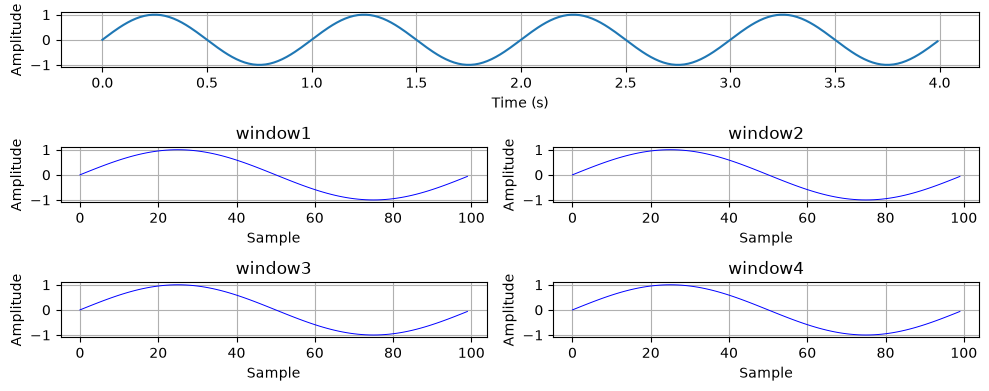

In [8]:
# Ex2.1 สร้างสัญญาณ Sine wave ที่ fs = 100 Hz, f = 1 Hz, A=1 เป็นเวลา 4 วินาที
# แบ่งสัญญาณออกเป็นหน้าต่างย่อย ขนาดหน้าต่าง 1 วินาที, overlap 0%
# plot ผลลัพธ์ด้วย subplot
t = time_axis(100, 4)
y = generate_sine(1, t, 1)

L = 100
H = int(1*L)
p0 = 0
p1 = L

plt.figure(figsize=(10, 4))
plt.subplot(3, 1, 1)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
for i in range(1, 4+1):
    x_win = y[p0:p1]

    plt.subplot(3,2,i+2)
    plt.plot(x_win, color='b', linewidth=0.7)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title(f"window{i}")
    plt.grid()

    p0 += H
    p1 += H

plt.tight_layout()
plt.savefig("image/670710258_w3_ex2-1.png")
plt.show()

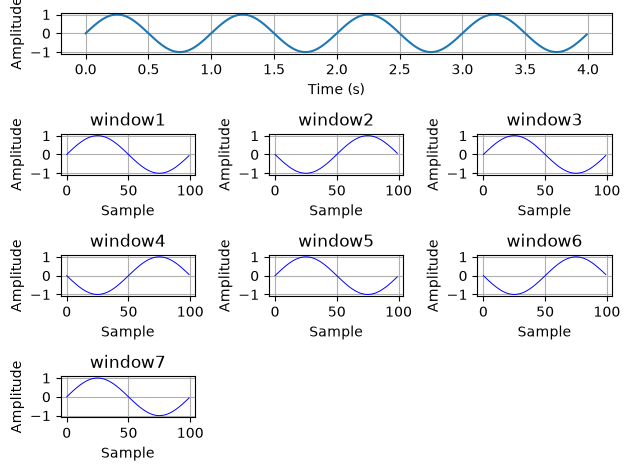

In [9]:
# Ex2.2 สร้างสัญญาณ Sine wave ที่ fs = 100 Hz, f = 1 Hz, A=1 เป็นเวลา 4 วินาที
# แบ่งสัญญาณออกเป็นหน้าต่างย่อย ขนาดหน้าต่าง 1 วินาที, overlap 50%
# plot ผลลัพธ์ด้วย subplot
t = time_axis(100, 4)
y = generate_sine(1, t, 1)

L = 100
H = int(0.5*L)
p0 = 0
p1 = L

# plt.figure(figsize=(10, 4))
plt.subplot(4, 1, 1)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
for i in range(1, 8):
    x_win = y[p0:p1]

    plt.subplot(4,3,i+3)
    plt.plot(x_win, color='b', linewidth=0.7)
    plt.xlabel("Sample")
    plt.ylabel("Amplitude")
    plt.title(f"window{i}")
    plt.grid()

    p0 += H
    p1 += H
plt.tight_layout()
plt.savefig("image/670710258_w3_ex2-2.png")
plt.show()


12


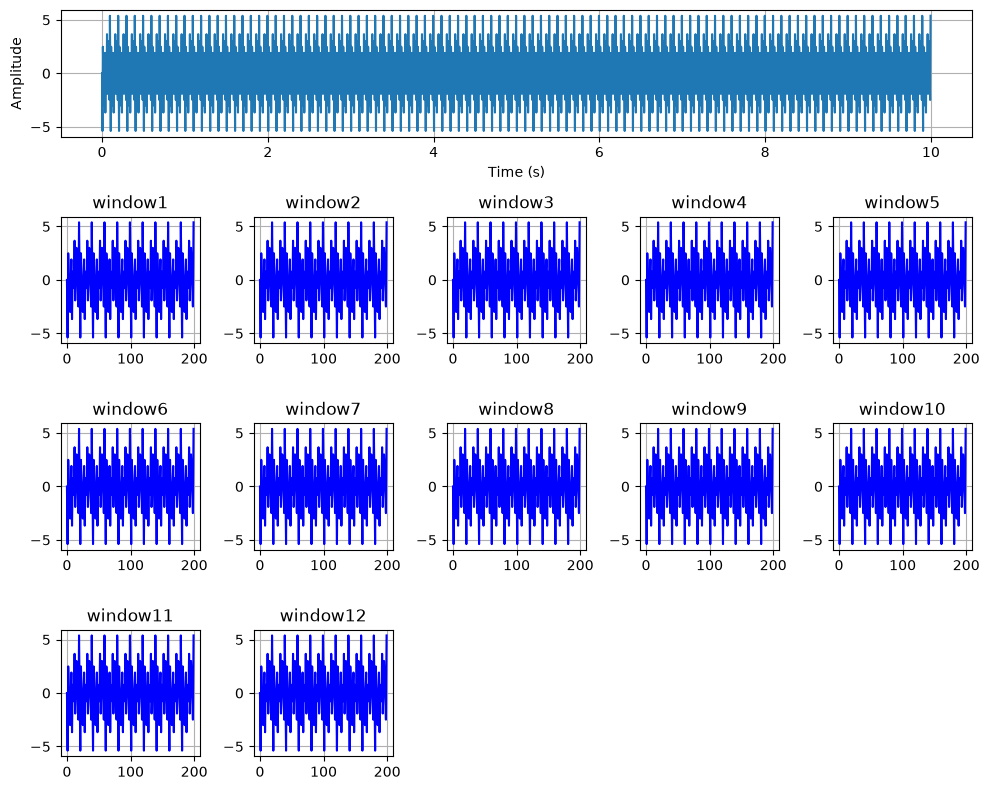

In [10]:
# Ex2.3 สร้างสัญญาณ Sine wave ที่มี เวลา, fs ตามที่กำหนดเอง โดยผสมกันของสัญญาณ 4 ความถี่
# แบ่งสัญญาณออกเป็นหน้าต่างย่อย โดยกำหนด ขนาดหน้าต่าง และ overlap ตามที่ต้องการ
# plot ผลลัพธ์ด้วย subplot
t = time_axis(200, 10)
y1 = generate_sine(f = 50, t= t, A = 2, p = -np.pi)
y2 = generate_sine(f = 60, t= t, A = -2, p = 0)
y3 = generate_sine(f = 10, t= t, A = 1, p = np.pi)
y4 = generate_sine(f = 80, t= t, A = 2, p = -np.pi)

y = y1 + y2 + y3 + y4
# 10, 1, 80
L = 1*200
H = int(0.8*L)
p0 = 0
p1 = L
n = 1 + round((10-1)/0.8)
print(n)


plt.figure(figsize=(10, 8))
plt.subplot(4, 1, 1)
plt.plot(t, y)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid()
for i in range(n):
    x_win = y[p0:p1]

    plt.subplot(4,5,i+6)
    plt.plot(x_win, color='b')
    plt.title(f"window{i+1}")
    plt.grid()

    p0 += H
    p1 += H
plt.tight_layout()
plt.savefig("image/670710258_w3_ex2-3.png")
plt.show()


Normalization

In [11]:
def zscore(x):
    return (x - np.mean(x)) / np.std(x)

data = np.array([10, 20, 30, 40, 50, 60])
data_norm = zscore(data)
print(data_norm)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
data_norm = scaler.fit_transform(data.reshape(-1, 1))
print(data_norm)

[-1.46385011 -0.87831007 -0.29277002  0.29277002  0.87831007  1.46385011]
[[-1.46385011]
 [-0.87831007]
 [-0.29277002]
 [ 0.29277002]
 [ 0.87831007]
 [ 1.46385011]]


In [12]:
data_norm1 = scaler.fit_transform(data.reshape(-2, 1))
print(data_norm1)

[[-1.46385011]
 [-0.87831007]
 [-0.29277002]
 [ 0.29277002]
 [ 0.87831007]
 [ 1.46385011]]


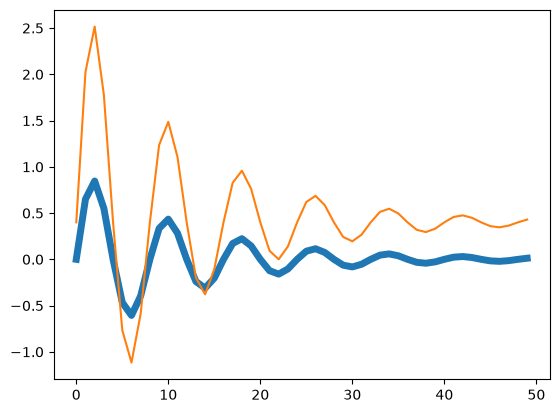

In [13]:
a = template
b = 2.5*template + 0.4 

plt.plot(a, linewidth = 5)
plt.plot(b)
plt.show()

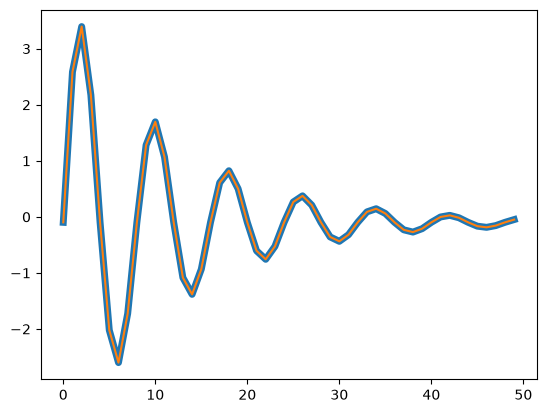

In [14]:
a = zscore(a)
b = zscore(b)
plt.plot(a, linewidth = 5)
plt.plot(b)
plt.show()

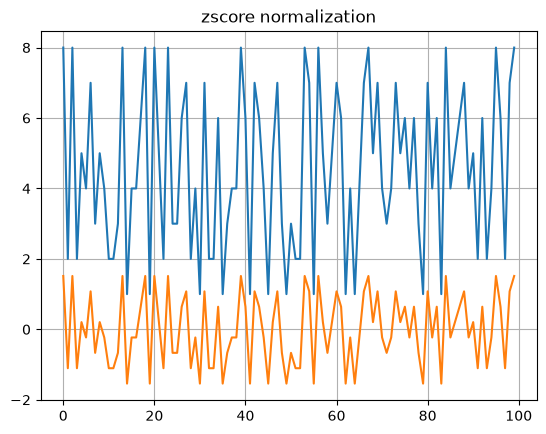

In [15]:
# Ex3 ทำ z-score normalization ข้อมูลนี้
data = np.array( [8,2,8,2,5,4,7,3,5,4,2,2,3,8,1,4,4,6,8,1,8,5,2,8,3,3,6,7,2,4,1,7,2,2,6,1,3
,4,4,8,6,1,7,6,4,1,5,7,3,1,3,2,2,8,7,1,8,5,3,5,7,6,1,4,1,4,7,8,5,7,4,3,4,7
,5,6,4,6,3,1,7,4,6,1,8,4,5,6,7,4,5,2,6,2,4,8,6,2,7,8] )
# แสดงกราฟก่อน-หลังทำ ในรูปเดียวกัน
data_norm = zscore(data)
plt.title("zscore normalization")
plt.plot(data)
plt.plot(data_norm)
plt.grid()
plt.savefig("image/670710258_w3_ex3.png")
plt.show()

In [16]:
data = [8,2,8,2,5,4]
print( np.array(data).reshape(2, 3) )

[[8 2 8]
 [2 5 4]]


In [17]:
# Ex4 reshape ข้อมูล ตอบในกระดาษ
data = [8,2,8,2,5,4]
# 4.1 (3, 2)
# print(np.array(data).reshape(3,2))
# 4.2 (1, 6)
# print(np.array(data).reshape(1,6))
# 4.3 (6, 1)
# print(np.array(data).reshape(6,1))
# 4.4 (2, 5)
# print(np.array(data).reshape(2,5))
# 4.5 (2, -1)
print(np.array(data).reshape(2,-1))
# 4.6 (-1, 2)
print(np.array(data).reshape(-1,2))

[[8 2 8]
 [2 5 4]]
[[8 2]
 [8 2]
 [5 4]]


Convolution

In [18]:
data = [1,0,1,3,4,3,0,9,2,2]
kernel = [1,2,1]
y = np.convolve(data, kernel, 'full')
print(y)
y = np.convolve(data, kernel, 'same')
print(y)
y = np.convolve(data, kernel, 'valid')
print(y)

[ 1  2  2  5 11 14 10 12 20 15  6  2]
[ 2  2  5 11 14 10 12 20 15  6]
[ 2  5 11 14 10 12 20 15]


In [19]:
data = [8,2,8,2,5,4,7,3,5,4,2,2,3]

Moving average

In [20]:
def moving_average(x, w):
    kernel = np.ones(w)/w
    # print("kernel: ", kernel)
    y = np.convolve(x, kernel, mode='same')
    return y

data = np.array([10, 20, 30, 40, 50, 60])
data_ma = moving_average(data, 3)
print(len(data), len(data_ma))
print(data_ma)

6 6
[10.         20.         30.         40.         50.         36.66666667]


In [21]:
data = np.array( [1, 3, 4, 2, 5, 6, 3, 4, 6, 4, 5, 3, 2, 1] )
data_ma = moving_average(data, 3)
print(len(data), len(data_ma))
print(data_ma)

14 14
[1.33333333 2.66666667 3.         3.66666667 4.33333333 4.66666667
 4.33333333 4.33333333 4.66666667 5.         4.         3.33333333
 2.         1.        ]


In [22]:
data = np.array( [1, 3, 4, 2, 5, 6, 3, 4, 6, 4, 5, 3, 2, 1] )
data_ma = moving_average(data, 3)
print(len(data), len(data_ma))
print(data_ma)

14 14
[1.33333333 2.66666667 3.         3.66666667 4.33333333 4.66666667
 4.33333333 4.33333333 4.66666667 5.         4.         3.33333333
 2.         1.        ]


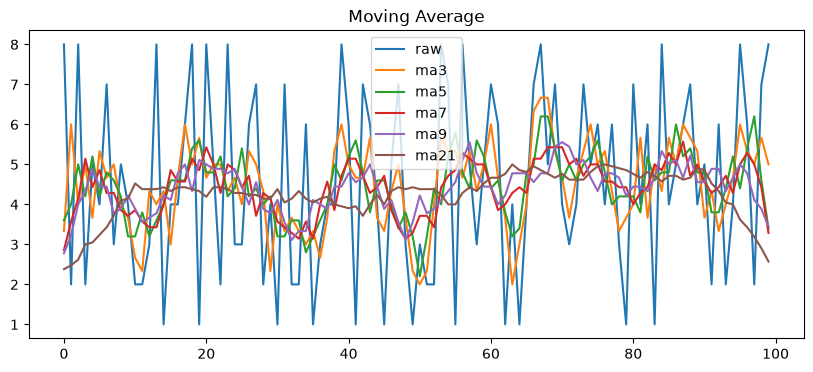

In [23]:
# Ex5 ทำ moving avg กับสัญญาณ และ plot สัญญาณเดิม กับสัญญาณที่กรองแล้วในรูปเดียวกัน
data = np.array( [8,2,8,2,5,4,7,3,5,4,2,2,3,8,1,4,4,6,8,1,8,5,2,8,3,3,6,7,2,4,1,7,2,2,6,1,3
,4,4,8,6,1,7,6,4,1,5,7,3,1,3,2,2,8,7,1,8,5,3,5,7,6,1,4,1,4,7,8,5,7,4,3,4,7
,5,6,4,6,3,1,7,4,6,1,8,4,5,6,7,4,5,2,6,2,4,8,6,2,7,8] )
# window = 3, 5, 7, และ 9 แบบ same
window = [3, 5, 7, 9, 21]
plt.figure(figsize = (10, 4))
plt.plot(data)
for w in window:
    data_ma = moving_average(data, w)
    plt.plot(data_ma)
plt.title("Moving Average")
plt.legend(['raw', 'ma3', 'ma5', 'ma7', 'ma9', 'ma21'])
plt.savefig("image/670710258_w3_ex5.png")

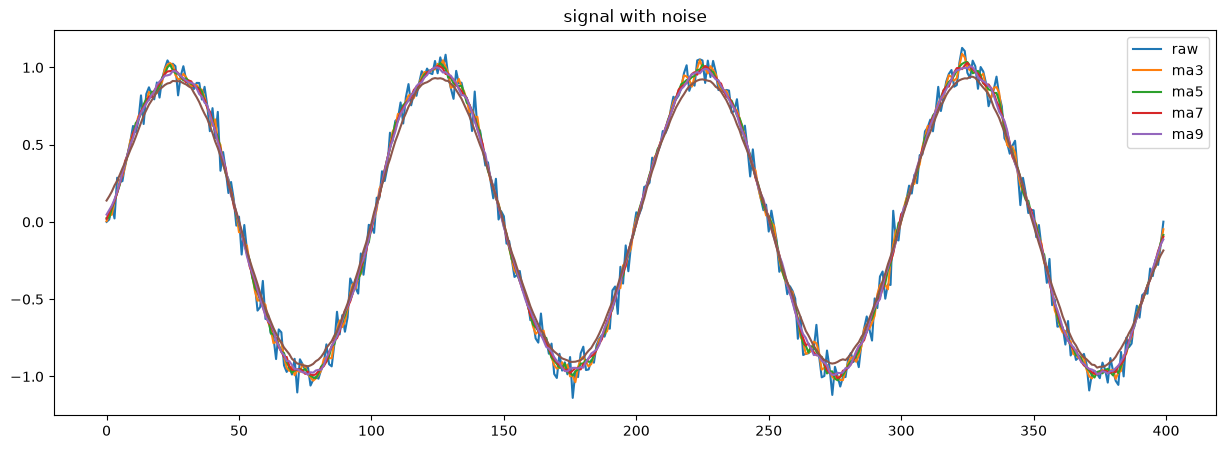

In [24]:
# Ex6 สร้างสัญญาณ sine ที่ fs = 100 Hz, f = 1 Hz, A=1 เป็นเวลา 4 วินาที
# นำสัญญาณไปบวกกัน noise แบบสุ่ม
# กรองสัญญาณแบบ moving avg ที่ window = 3, 5, 7, และ 9 แบบ same
t = time_axis(100, 4)

data = generate_sine(1,t, 1)
noise = np.random.normal(0, 0.08, len(data))
data = data +noise
plt.figure(figsize=(15, 5))
plt.plot(data)
# plt.plot(noise)
for w in window:
    data_ma = moving_average(data, w)
    plt.plot(data_ma)
plt.title("signal with noise")
plt.legend(['raw', 'ma3', 'ma5', 'ma7', 'ma9'])
plt.savefig("image/670710258_w3_ex6.png")

Savitzky-Golay

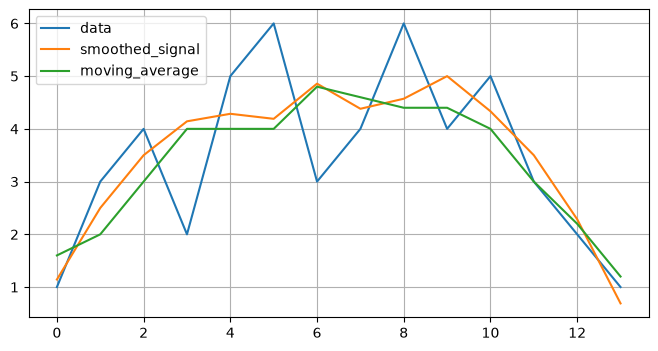

In [40]:
from scipy.signal import savgol_filter

data = np.array( [1, 3, 4, 2, 5, 6, 3, 4, 6, 4, 5, 3, 2, 1] )

smoothed_signal = savgol_filter(data, window_length=7, polyorder=2)

data_ma = moving_average(data, 5)
# print(smoothed_signal)
plt.figure(figsize = (8, 4))
plt.plot(data, label = 'data')
plt.plot(smoothed_signal, label = 'smoothed_signal')
plt.plot(data_ma, label = 'moving_average')
plt.legend()
plt.grid()

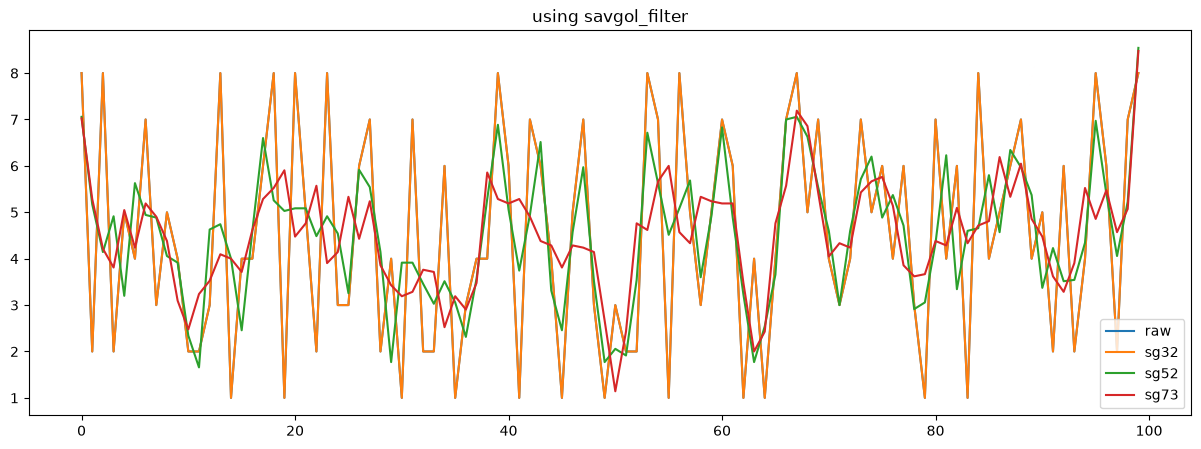

In [55]:
# Ex 7. ทำ sg-filter กับสัญญาณ
data = np.array( [8,2,8,2,5,4,7,3,5,4,2,2,3,8,1,4,4,6,8,1,8,5,2,8,3,3,6,7,2,4,1,7,2,2,6,1,3
,4,4,8,6,1,7,6,4,1,5,7,3,1,3,2,2,8,7,1,8,5,3,5,7,6,1,4,1,4,7,8,5,7,4,3,4,7
,5,6,4,6,3,1,7,4,6,1,8,4,5,6,7,4,5,2,6,2,4,8,6,2,7,8] )
# กำหนด window_size และ order เป็น ( (3, 2), (5, 2), (7, 3) ) 
# plot ทั้ง 4 สัญญาณในกราฟเดียวกัน
# smoothed_signal1 = savgol_filter(data, window_length=3, polyorder=2)
# smoothed_signal2 = savgol_filter(data, window_length=5, polyorder=2)
# smoothed_signal3 = savgol_filter(data, window_length=7, polyorder=3)
window_size = [[3,2], [5, 2], [7, 3]]


plt.figure(figsize=(15, 5))
plt.title("using savgol_filter")
plt.plot(data, label = "raw")
for ws in window_size:
    smoothed_signal = savgol_filter(data, window_length= ws[0], polyorder=ws[1])
    plt.plot(smoothed_signal, label = f"sg{ws[0]}{ws[1]}")

# plt.plot(smoothed_signal1)
# plt.plot(smoothed_signal2)
# plt.plot(smoothed_signal3)
# plt.legend(['raw', 'sg32', 'sg52', 'sg73'])
plt.legend()
# plt.savefig("image/670710258_w3_ex7.png")

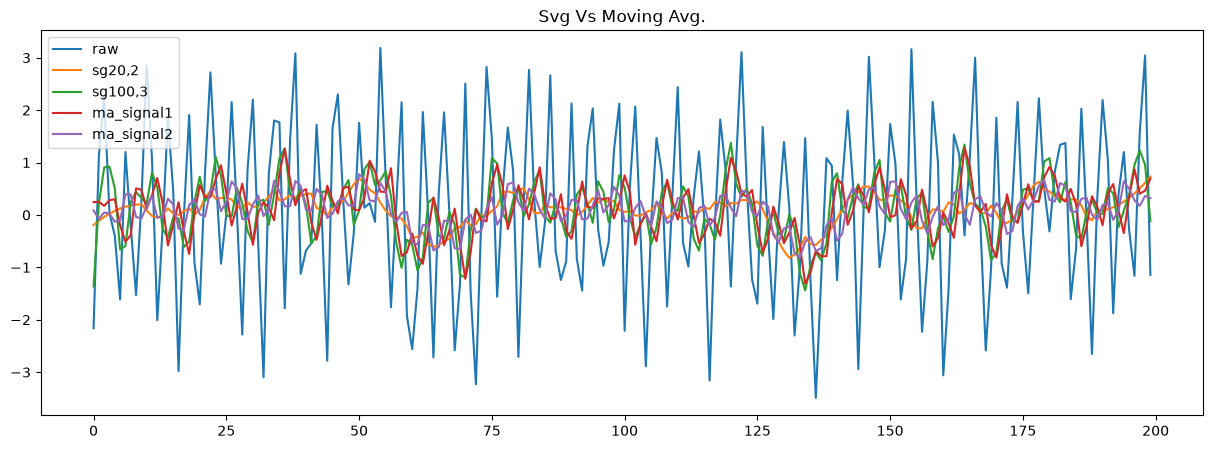

In [72]:
fs = 200
duration = 1
f = 50
t = time_axis(fs, duration)
data = generate_sine(f, t, A = 2, p = -np.pi/2)
noise = np.random.normal(0, 0.88, len(data))
data += noise


smoothed_signal1 = savgol_filter(data, window_length= 20, polyorder=2)
smoothed_signal2 = savgol_filter(data, window_length= 10, polyorder=3)
ma_signal1 = moving_average(data, 5)
ma_signal2 = moving_average(data, 10)


plt.figure(figsize=(15, 5))
plt.title("Svg Vs Moving Avg.")
plt.plot(data, label = "raw")
plt.plot(smoothed_signal1, label = f"sg20,2")
plt.plot(smoothed_signal2, label = f"sg100,3")
plt.plot(ma_signal1, label = "ma_signal1")
plt.plot(ma_signal2, label = "ma_signal2")
plt.legend()
plt.savefig("image/670710258_w3_ex8.png")

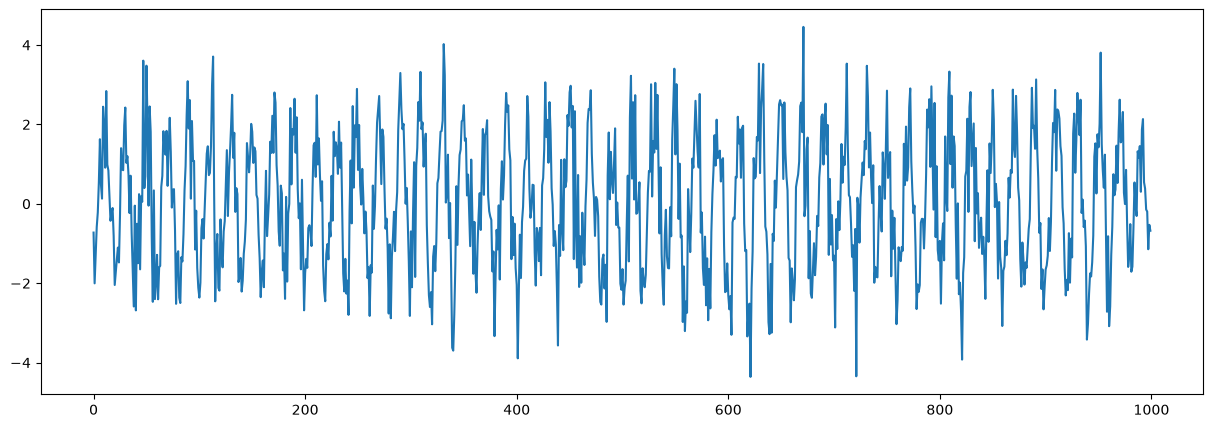

In [60]:
plt.figure(figsize = (15, 5))
plt.plot(data)

Euclidean distance

0.8602325267042626
0.8602325267042626


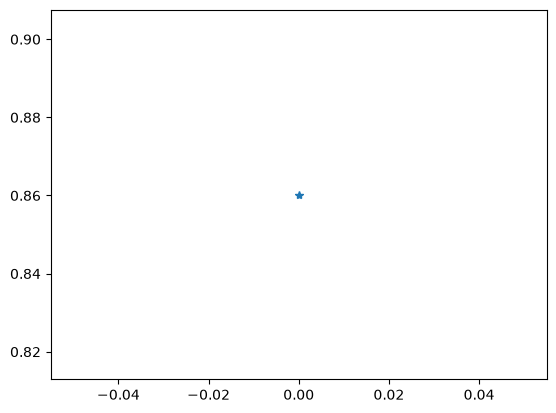

In [80]:
def euclidean_distance(a, b):
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    return float(np.sqrt(np.sum((a - b)**2)))

a = [0.2, 0.3]
b = [0.9, 0.8]
dist = euclidean_distance(a, b)
print(dist)
import math
dist = math.dist(a, b)
print(dist)
plt.plot(dist, marker = '*')

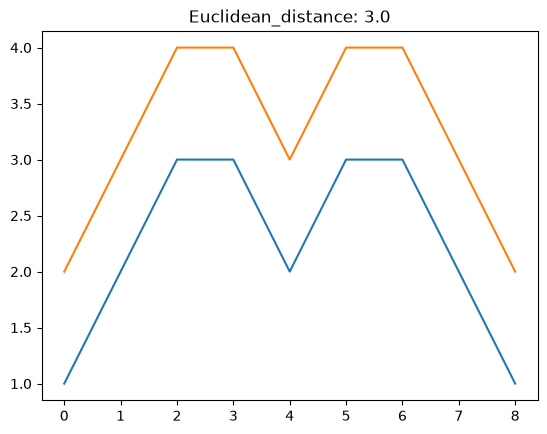

In [94]:
# Ex 8. คำนวน euclidean distance ของเวกเตอร์ที่กำหนด
vec1 = [1, 2, 3, 3, 2, 3, 3, 2, 1]
vec2 = [2, 3, 4, 4, 3, 4, 4, 3, 2]

# normalize
# vec1= zscore(vec1)
# vec2 = zscore(vec2)

# plot สัญญาณทั้ง 2 และกำหนดชื่อรูปเป็น ค่าระยะห่าง แบบทศนิยม 2 ตำแหน่ง
dist = euclidean_distance(vec1, vec2)
plt.plot(vec1)
plt.plot(vec2)
plt.title(f"Euclidean_distance: {dist}")
plt.savefig("image/670710258_w3_ex8-1.png")

3.0


DTW

In [29]:
def dtw_distance(a, b, band=None):
    n, m = len(a), len(b)
    D = np.full((n+1, m+1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n+1):
        for j in range(1, m+1):
            if band is not None and abs(i*m/n - j) > band:   # band around the diagonal
                continue
            cost = (a[i-1] - b[j-1])**2
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    path = []
    i, j = n, m
    while i > 0 and j > 0:
        path.append((i-1, j-1))
        step = int(np.argmin([D[i-1, j-1], D[i-1, j], D[i, j-1]]))
        i, j = [(i-1, j-1), (i-1, j), (i, j-1)][step]
    path.reverse()
    return float(np.sqrt(D[n, m]/len(path))), D[1:, 1:], path   # path-length normalized

slow = make_event(fs, A=1.0, stretch=1.4)          # machine running 1.4x slower
delayed = np.concatenate([np.zeros(20), template])  # same event, 0.1 sec late
pad = np.zeros(len(slow) - len(template))
print("template", len(template), "slow", len(slow), "delayed", len(delayed))
print("euclidean(template, slow)    =", round(euclidean_distance(np.concatenate([template, pad]), slow), 3))
print("euclidean(template, delayed) =", round(euclidean_distance(np.concatenate([template, pad]), delayed), 3))
d_dtw, D, path = dtw_distance(zscore(template), zscore(slow))
print("dtw(template, slow)          =", round(d_dtw, 3), "path length", len(path))

template 50 slow 70 delayed 70
euclidean(template, slow)    = 2.276
euclidean(template, delayed) = 2.653
dtw(template, slow)          = 0.209 path length 70
